#Predicting Housing Prices: Develop a regression model to predict house prices based on features like location, size, and amenities.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4/Housing_Price_Dataset_120_Records.csv")

In [ ]:
df.head()

,HouseID,Location,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Furnished,Price
0,H001,Rural,1028,1,3,0,0,5,Yes,55.84
1,H002,Rural,2316,1,4,0,0,3,Yes,103.88
2,H003,Urban,1834,1,2,2,2,23,No,86.42
3,H004,Urban,1719,3,1,0,2,14,No,96.77
4,H005,Suburban,1118,2,3,0,0,13,Yes,63.94


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   HouseID    120 non-null    object 
 1   Location   120 non-null    object 
 2   Area_sqft  120 non-null    int64  
 3   Bedrooms   120 non-null    int64  
 4   Bathrooms  120 non-null    int64  
 5   Balcony    120 non-null    int64  
 6   Parking    120 non-null    int64  
 7   Age_Years  120 non-null    int64  
 8   Furnished  120 non-null    object 
 9   Price      120 non-null    float64
dtypes: float64(1), int64(6), object(3)
memory usage: 9.5+ KB


In [ ]:
df.isnull().sum()

,0
HouseID,0
Location,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Balcony,0
Parking,0
Age_Years,0
Furnished,0
Price,0


In [ ]:
df = df.drop("HouseID" , axis = 1)

In [ ]:

df = pd.get_dummies(df, columns=['Location', 'Furnished'], drop_first=T+e)

X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Price,Location_Suburban,Location_Urban,Furnished_Yes
0,1028,1,3,0,0,5,55.84,False,False,True
1,2316,1,4,0,0,3,103.88,False,False,True
2,1834,1,2,2,2,23,86.42,False,True,False
3,1719,3,1,0,2,14,96.77,False,True,False
4,1118,2,3,0,0,13,63.94,True,False,True


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([101.39,  66.9 ,  63.94,  60.96,  62.13,  58.67,  35.35,  66.31,
       102.29,  63.55,  74.89, 114.76, 131.89,  77.38,  63.54, 113.85,
        87.52,  55.84, 104.41,  61.74, 129.28,  95.59, 101.56, 115.42])

In [ ]:
lr.predict(X_test_scaled[0].reshape(1, -1))

array([101.39])

In [ ]:
price_correlations = df.corr(numeric_only=True)['Price'].sort_values(ascending=False)
display(price_correlations)

,Price
Price,1.000000
Area_sqft,0.717382
Location_Urban,0.459478
Bathrooms,0.333676
Bedrooms,0.154453
Parking,0.066709
Furnished_Yes,-0.046588
Balcony,-0.083178
Location_Suburban,-0.143702
Age_Years,-0.440987


In [ ]:
lr.intercept_


np.float64(85.26947916666667)

In [ ]:
lr.coef_

array([ 1.50871230e+01,  5.49398938e+00,  7.47031161e+00, -4.21884749e-15,
        3.98258743e+00, -8.63680352e+00,  4.78260012e+00,  1.13632418e+01,
       -2.83106871e-15])

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mse

2.6716089323484935e-28

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

1.0

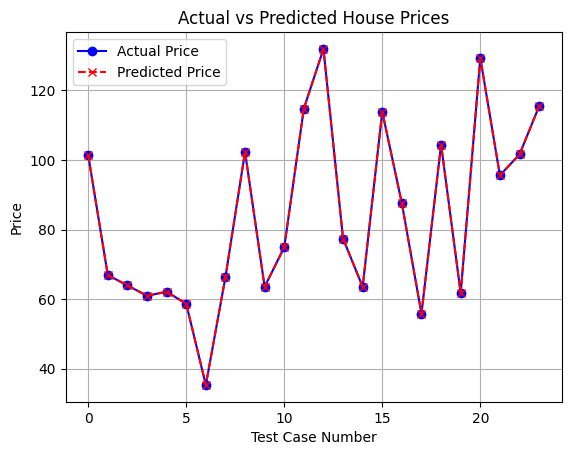

In [ ]:
import matplotlib.pyplot as plt
plt.plot(y_test.values, label='Actual Price', color='blue', marker='o')
plt.plot(y_pred, label='Predicted Price', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Test Case Number')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.savefig('actual_vs_predicted.png')

In [ ]:
import pickle


In [ ]:
folder_path = '/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4'

with open(folder_path + 'house_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open(folder_path + 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and Scaler saved successfully to Google Drive!")

Model and Scaler saved successfully to Google Drive!


In [ ]:
import pickle
import pandas as pd

folder_path = '/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4'

with open(folder_path + 'house_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open(folder_path + 'scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("Model and Scaler loaded successfully!")

Model and Scaler loaded successfully!


Now, let's create some example 'new' data. It's important that this new data has the same features and column order as your original training data (`X_train`).

In [ ]:

new_house_data = pd.DataFrame({
    'Area_sqft': [2000],
    'Bedrooms': [3],
    'Bathrooms': [2],
    'Balcony': [1],
    'Parking': [1],
    'Age_Years': [10],
    'Location_Suburban': [False],
    'Location_Urban': [True],
    'Furnished_Yes': [True]
})

display(new_house_data)

,Area_sqft,Bedrooms,Bathrooms,Balcony,Parking,Age_Years,Location_Suburban,Location_Urban,Furnished_Yes
0,2000,3,2,1,1,10,False,True,True


Next, we need to scale this new data using the *loaded scaler* (not a new one). This is crucial for consistent predictions.

In [ ]:

new_house_data_scaled = loaded_scaler.transform(new_house_data)
predicted_price = loaded_model.predict(new_house_data_scaled)

print(f"The predicted price for the new house is: ${predicted_price[0]:.2f}")

The predicted price for the new house is: $112.00


This process ensures that your model always receives input data in the format it was trained on, leading to reliable predictions.